1) Importe o conjunto de dados con do no arquivo Base Mercado.xlsx para o 
ambiente de análise. 

In [ ]:
import pandas as pd

# Lê o arquivo Excel
df = pd.read_excel("Base_mercado.xlsx")

# Converte cada coluna em uma lista e salva num dicionário
atributos = {col: df[col].tolist() for col in df.columns}

# Exibe os nomes das colunas e os valores
for nome_coluna, valores in atributos.items():
    print(f"{nome_coluna}: {valores}")

# para printar algum atributo sozinho
print(df['valor']) 


2) Construa uma tabela de distribuição de frequências para a variável escolaridade 
do cliente, apresentando frequência absoluta, percentuais e acumuladas. Não 
apresente possíveis dados faltantes existentes. 

In [ ]:
import pandas as pd

# Lê a planilha
df = pd.read_excel("Base_mercado.xlsx")

# Remove dados faltantes da variável 'Escolaridade'
df = df[df['escolaridade'].notna()]

# Calcula frequências
frequencia_abs = df['escolaridade'].value_counts()
frequencia_rel = df['escolaridade'].value_counts(normalize=True) * 100
frequencia_abs_acumulada = frequencia_abs.cumsum()
frequencia_rel_acumulada = frequencia_rel.cumsum()

# Cria a tabela
tabela_freq = pd.DataFrame({
    'Frequência Absoluta': frequencia_abs,
    'Frequência Relativa (%)': frequencia_rel.round(2),
    'Frequência Acumulada': frequencia_abs_acumulada,
    'Frequência Relativa Acumulada (%)': frequencia_rel_acumulada.round(2)
})

# Exibe a tabela
print(tabela_freq)


3) Construa uma tabela de distribuição de frequências para a variável dia da semana 
em que a compra foi registrada, apresentando somente frequência absoluta e 
percentual. Apresente possíveis dados faltantes existentes. 

In [ ]:
import pandas as pd

# Lê o arquivo Excel
df = pd.read_excel("Base_mercado.xlsx")

# Calcula frequências
frequencia_abs = df['semana'].value_counts(dropna=False)
frequencia_rel = df['semana'].value_counts(normalize=True, dropna=False) * 100

# Monta a tabela
tabela_freq = pd.DataFrame({
    'Frequência Absoluta': frequencia_abs,
    'Frequência Relativa (%)': frequencia_rel.round(2)
})

# Exibe a tabela
print(tabela_freq)


4) Construa uma tabela de distribuição de frequências para a variável valor da 
compra de modo que a primeira classe comece no valor 45 reais e todas as 
classes possuam amplitude de 35 reais. Apresente as frequências absoluta, 
percentuais e acumuladas.  

In [ ]:
import pandas as pd
import numpy as np

# Lê a base de dados
df = pd.read_excel("Base_mercado.xlsx")

# Remove valores ausentes da variável "valor"
valores = df['valor'].dropna()

# Parâmetros de classe
min_valor = 45
amplitude = 35
max_valor = valores.max()
bins = np.arange(min_valor, max_valor + amplitude, amplitude)

# Agrupamento em classes
classes = pd.cut(valores, bins=bins, right=False)

# Tabela de frequências
frequencias = classes.value_counts(sort=False).to_frame(name='Frequência Absoluta')
frequencias['Frequência Relativa (%)'] = (frequencias['Frequência Absoluta'] / len(valores) * 100).round(2)
frequencias['Frequência Acumulada'] = frequencias['Frequência Absoluta'].cumsum()
frequencias['Frequência Relativa Acumulada (%)'] = frequencias['Frequência Relativa (%)'].cumsum().round(2)

# Exibe a tabela
print(frequencias)


5) Calcule a média do valor da compra segmentada por grau de escolaridade do 
cliente. 

In [ ]:
# Agrupa por grau de escolaridade e calcula a média da coluna 'pagamento'
media_por_escolaridade = df.groupby('escolaridade')['valor'].mean()

# Exibe o resultado
print(media_por_escolaridade)


6) Calcule o percentil 30 (P30) da variável valor da compra, estra ficado por sexo 
do cliente e dia da semana da compra. Ou seja, encontre o valor abaixo do qual 
se encontram 30% dos dados para cada combinação dessas variáveis. 

In [ ]:
# Calcula o percentil 30 da variável 'valor', por sexo e dia da semana
p30 = df.groupby(['sexo', 'semana'])['valor'].quantile(0.3)

# Exibe o resultado
print(p30)


7) Calcule a variância e o desvio padrão para todas as variáveis numéricas presentes no conjunto de dados. Apresente os resultados organizados em uma tabela. 

In [ ]:
# Remove as colunas indesejadas
df_filtrado = df.drop(columns=['pagamento','sexo', 'semana', 'outromercado', 'bairro', 'escolaridade'], errors='ignore')

# Seleciona apenas as colunas numéricas
numericas = df_filtrado.select_dtypes(include='number')

# Calcula variância e desvio padrão
variancia = numericas.var()
desvio_padrao = numericas.std()

# Organiza em uma tabela
tabela_disp = pd.DataFrame({
    'Variância': variancia.round(2),
    'Desvio Padrão': desvio_padrao.round(2)
})

# Exibe a tabela
print(tabela_disp)


8) Elabore um gráfico de barras ou colunas para representar a distribuição da variável grau de escolaridade do cliente. 

In [ ]:
import matplotlib.pyplot as plt

# Conta a frequência de cada categoria
df['escolaridade'].value_counts().plot(kind='bar', color='pink', edgecolor='black')

# Títulos e rótulos
plt.title('Distribuição do Grau de Escolaridade dos Clientes')
plt.xlabel('Grau de Escolaridade')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.tight_layout()

# Exibe o gráfico
plt.show()


9) Crie um histograma para a variável número de produtos, utilizando 25 intervalos. 

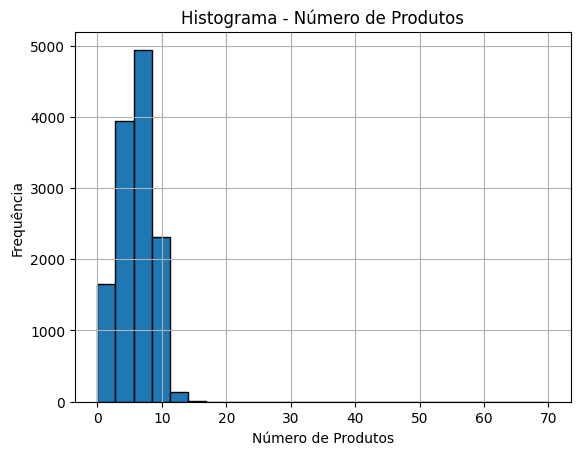

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que a variável esteja na coluna 'numero_produtos'
dados = df['numero_prod']

# Criar histograma com 25 intervalos
plt.hist(dados, bins= 25, edgecolor='black')
plt.title('Histograma - Número de Produtos')
plt.xlabel('Número de Produtos')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()


10) Construa um boxplot interativo para visualizar a distribuição da variável valor da compra. 

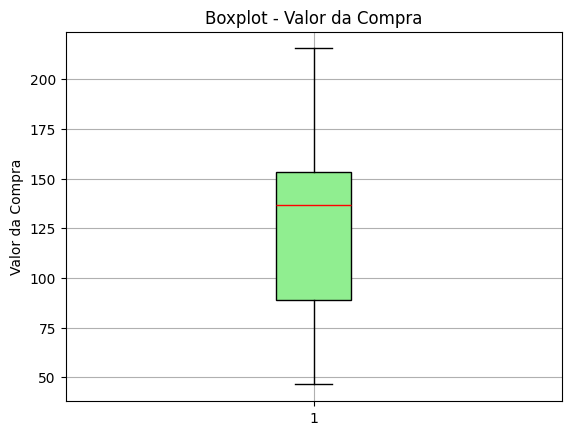

In [16]:
import matplotlib.pyplot as plt

# Supondo que a variável esteja na coluna 'valor'
dados = df['valor'].dropna()  # remove valores ausentes, se houver

# Criar o boxplot
plt.boxplot(dados, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='black', alpha=0.5))

plt.title('Boxplot - Valor da Compra')
plt.ylabel('Valor da Compra')
plt.grid(True)
plt.show()



11) Apresente um gráfico de setores (pizza) para representar a variável filhos,mostrando a proporção de clientes com diferentes quan dades de filhos. 

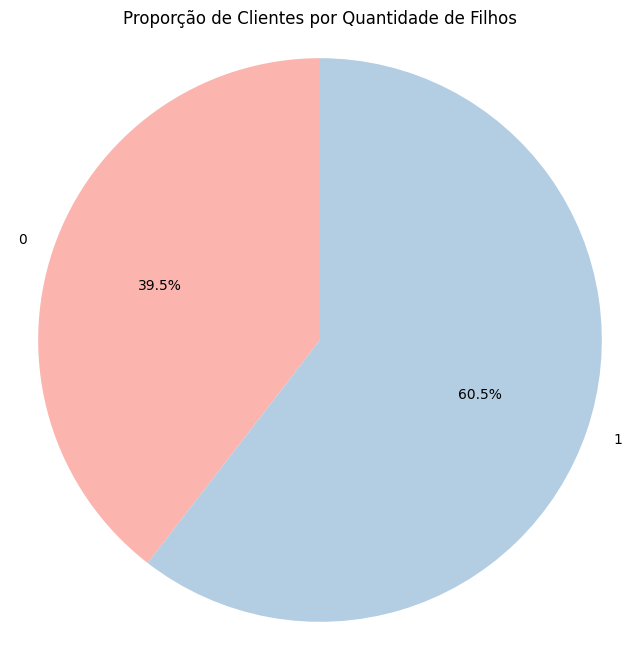

In [17]:
import matplotlib.pyplot as plt

# Contar quantos clientes têm cada quantidade de filhos
contagem_filhos = df['filhos'].value_counts().sort_index()

# Rótulos (quantidade de filhos) e valores (frequência)
labels = contagem_filhos.index
sizes = contagem_filhos.values

# Criar gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=plt.cm.Pastel1.colors)
plt.title('Proporção de Clientes por Quantidade de Filhos')
plt.axis('equal')  # Garante que o círculo fique redondo
plt.show()
